# Hydrogen Dispersion in V-Room: Notional Nozzle Theory & Derivation

**Project**: OpenFOAM v2406 — H2 leakage dispersion in a V-shaped room  
**Scenario**: Accidental H2 release from a 500 bar pressure vessel through an orifice (area ≥ 3.5 mm²)  
**Solver**: `reactingFoam` (compressible, pressure-based PIMPLE, no combustion/chemistry)  
**Date**: 2026-04

---

## Contents
1. [Physical Problem & Motivation](#1-physical-problem)
2. [Choked Flow Theory](#2-choked-flow-theory)
3. [Why the Actual Orifice Cannot Be Simulated Directly](#3-why-not-direct)
4. [Notional Nozzle Concept](#4-notional-nozzle-concept)
5. [Model Variants](#5-model-variants)
6. [Birch 1987 Derivation — U_notional and D_notional](#6-birch-1987-derivation)
7. [Numerical Example: 500 bar, 3.5 mm² orifice](#7-numerical-example)
8. [OpenFOAM Boundary Conditions](#8-openfoam-bcs)
9. [References](#9-references)

---
## 1. Physical Problem

A hydrogen storage vessel at $P_0 = 500$ bar leaks through a small orifice into a confined room at $P_{amb} = 1$ atm.

The pressure ratio:
$$\frac{P_0}{P_{amb}} = \frac{500 \times 10^5}{101325} \approx 4935$$

The **critical pressure ratio** for choked (sonic) flow is:
$$\left(\frac{P_{throat}}{P_0}\right)_{critical} = \left(\frac{2}{\gamma+1}\right)^{\gamma/(\gamma-1)}$$

For H2 with $\gamma = 1.4$:
$$\left(\frac{P_{throat}}{P_0}\right)_{critical} = \left(\frac{2}{2.4}\right)^{3.5} \approx 0.528$$

Since $P_{amb}/P_0 \approx 0.0002 \ll 0.528$, the flow is **always choked** — the orifice exit is always at Mach 1, regardless of the exact vessel pressure (as long as $P_0 > 1.89$ bar).

### Near-field structure of an underexpanded jet

```
Vessel (500 bar) │ orifice │         Room (1 bar)
                 │  Mach 1 │
                 │  ←d_0→  │  ←── expansion fans
                 │         │         ↓
                 │         │    barrel shock (oblique)
                 │         │         ↓
                 │         │    Mach disk (normal shock)
                 │         │         ↓
                 │         │    subsonic turbulent jet
                 │         │         ↓
                 │         │    far-field H2 cloud  ← WE CARE ABOUT THIS
```

The near-field shock structure (barrel shock + Mach disk) is confined to a region of **a few orifice diameters** in extent. For a 2.1 mm orifice, this is only ~5–20 mm. The **far-field dispersion** (meters scale) is what determines H2 cloud formation and ignition risk.

---
## 2. Choked Flow Theory

### Isentropic relations at the throat (Mach 1)

For an ideal gas with specific heat ratio $\gamma$ and specific gas constant $R$:

**Temperature at throat:**
$$T_{throat} = \frac{T_0}{1 + \dfrac{\gamma-1}{2} \cdot M^2}\bigg|_{M=1} = \frac{T_0}{\dfrac{\gamma+1}{2}} = \frac{2 T_0}{\gamma+1}$$

**Pressure at throat:**
$$P_{throat} = P_0 \left(\frac{2}{\gamma+1}\right)^{\gamma/(\gamma-1)}$$

**Density at throat:**
$$\rho_{throat} = \frac{P_{throat}}{R \, T_{throat}}$$

**Velocity at throat (= speed of sound):**
$$V_{throat} = a_{throat} = \sqrt{\gamma R T_{throat}}$$

### H2 gas properties used

| Property | Symbol | Value |
|----------|--------|-------|
| Specific heat ratio | $\gamma$ | 1.4 |
| Molar mass | $M_w$ | 2.016 g/mol |
| Specific gas constant | $R_{H2} = R_u / M_w$ | 4124 J/(kg·K) |
| Stagnation temperature | $T_0$ | 286.15 K (ambient) |

In [6]:
import numpy as np

# H2 gas properties
gamma = 1.4
Ru = 8.314          # Universal gas constant [J/(mol·K)]
Mw_H2 = 2.016e-3    # Molar mass H2 [kg/mol]
R_H2 = Ru / Mw_H2  # Specific gas constant H2 [J/(kg·K)]

# Stagnation conditions (vessel)
P0 = 500e5          # [Pa]
T0 = 286.15         # [K]
P_amb = 101325.0    # [Pa]
T_amb = 286.15      # [K]

print(f"R_H2 = {R_H2:.1f} J/(kg·K)")
print(f"Pressure ratio P0/P_amb = {P0/P_amb:.0f}")
print(f"Critical pressure ratio = {(2/(gamma+1))**(gamma/(gamma-1)):.4f}")
print(f"Flow is choked: {P_amb/P0 < (2/(gamma+1))**(gamma/(gamma-1))}")

# Throat conditions (Mach 1)
T_throat = 2 * T0 / (gamma + 1)
P_throat = P0 * (2 / (gamma + 1))**(gamma / (gamma - 1))
rho_throat = P_throat / (R_H2 * T_throat)
V_throat = np.sqrt(gamma * R_H2 * T_throat)

print(f"\n--- Throat (orifice exit) conditions ---")
print(f"T_throat  = {T_throat:.1f} K")
print(f"P_throat  = {P_throat/1e5:.1f} bar")
print(f"rho_throat = {rho_throat:.2f} kg/m³")
print(f"V_throat  = {V_throat:.1f} m/s  (Mach 1 in H2)")

R_H2 = 4124.0 J/(kg·K)
Pressure ratio P0/P_amb = 493
Critical pressure ratio = 0.5283
Flow is choked: True

--- Throat (orifice exit) conditions ---
T_throat  = 238.5 K
P_throat  = 264.1 bar
rho_throat = 26.86 kg/m³
V_throat  = 1173.4 m/s  (Mach 1 in H2)


---
## 3. Why the Actual Orifice Cannot Be Simulated Directly

### Problem 1 — The jet is strongly supersonic in room air

The speed of sound in room air at 286 K:
$$a_{air} = \sqrt{\gamma_{air} R_{air} T_{amb}} \approx \sqrt{1.4 \times 287 \times 286} \approx 338 \text{ m/s}$$

The H2 jet exits at $V_{throat} \approx 1175$ m/s, giving:
$$M_{jet,air} = \frac{V_{throat}}{a_{air}} \approx \frac{1175}{338} \approx 3.5$$

This is a **strongly underexpanded supersonic jet** in air — with Mach disk, barrel shocks, and expansion fans.

### Problem 2 — `reactingFoam` uses pressure-based PIMPLE

`reactingFoam` is a **pressure-based** solver (PIMPLE algorithm). It is:
- ✅ Suitable for: low-Mach compressible flow, buoyancy-driven flow, subsonic reacting flow
- ❌ Not suitable for: strong shocks, Mach disks, underexpanded jets requiring shock-capturing

Shock-capturing requires density-based solvers with Riemann solvers (e.g., `rhoCentralFoam`, `sonicFoam`), not PIMPLE.

### What happens when you force it:
- Expansion fans cool H2 to below 200 K → hits JANAF thermodynamic table lower bound
- Shock compression heats air cells to > 2000 K
- Simulation crashes or is stopped by temperature monitor
- **This is exactly what happened in case04** (stopped at t ≈ 2.2×10⁻⁴ s, T_min = 200 K)

### Problem 3 — Mesh resolution

Resolving the 1 cm orifice and its shock structure requires sub-mm cell sizes near the orifice. For a room-scale domain (meters), this creates extreme cell count ratios and is computationally intractable.

---
## 4. Notional Nozzle Concept

### Core idea

The Mach disk acts as a **thermodynamic reset**: across the normal shock, the flow transitions from supersonic back to subsonic, and pressure returns to near-ambient. After the Mach disk, the jet behaves like a **regular subsonic turbulent jet** and has "forgotten" the detailed shock structure.

The notional nozzle replaces the entire near-field shock region with a **virtual inlet plane** located conceptually at or after the Mach disk, with:
- Pressure = ambient
- Larger diameter (to compensate for lower density)
- Adjusted velocity (to preserve mass and momentum flux)

```
REALITY:                              NOTIONAL NOZZLE MODEL:

[500 bar vessel]                      ┌─────────────────────┐
    │                                 │  Skip near-field    │
    ↓ 1 cm orifice (Mach 1)          │  shock entirely     │
[barrel shock]           ───────►    └─────────────────────┘
[Mach disk]                                   │
[subsonic jet]                       [virtual inlet: ~23 cm]
    │                                [P_amb, V_n, T_n, H2=1]
    ↓                                         │
[far-field H2 cloud]                 [far-field H2 cloud]  ← identical!
```

### Physical analogy

Imagine a mountain river entering a lake through a narrow gorge with violent rapids. If you want to model **water circulation in the lake**, you don't need to simulate the gorge. You just place an **equivalent calm-water inlet** at the gorge exit with the correct flow rate and momentum. The lake dynamics are identical.

### Validity

The approach is valid when:
- You are interested in **far-field dispersion** (distances >> orifice diameter)
- The shock region is small compared to the domain of interest
- The flow after the Mach disk is approximately at ambient pressure (satisfied for large pressure ratios)

---
## 5. Model Variants

Four main notional nozzle models exist, differing in which conservation laws they apply:

| Model | Mass | Momentum | Energy | Notes |
|-------|------|----------|--------|-------|
| **Birch 1984** | ✅ | ❌ | ❌ | Assumes sonic exit, simplest |
| **Ewan & Moodie 1986** | ✅ | ❌ | ❌ | Similar to Birch 1984 |
| **Birch 1987** | ✅ | ✅ | ❌ | Includes pressure thrust, recommended |
| **Schefer 2007** | ✅ | ✅ | ✅ | Most rigorous, best for temperature |

**Baraldi et al. (2012)** benchmarked all models against experimental H2 concentration data and found **Birch 1987 and Schefer** gave best agreement.

### Birch 1984 — mass conservation only

Assumes the notional nozzle velocity equals the ambient speed of sound:
$$V_n = a_{amb} = \sqrt{\gamma R T_{amb}}$$

Then diameter from mass conservation:
$$D_n = D_0 \sqrt{\frac{\rho_{throat}}{\rho_{amb}}}$$

Simple but underestimates momentum, leading to shorter predicted jet penetration.

### Birch 1987 — mass + momentum conservation *(recommended)*

See full derivation in Section 6.

### Schefer 2007 — mass + momentum + energy

Adds energy equation to Birch 1987, allowing $T_n \neq T_{amb}$. The temperature at the notional nozzle comes from enthalpy conservation:
$$h_n + \frac{V_n^2}{2} = h_{throat} + \frac{V_{throat}^2}{2}$$
$$c_p T_n + \frac{V_n^2}{2} = c_p T_{throat} + \frac{V_{throat}^2}{2}$$

---
## 6. Birch 1987 Derivation — $U_{notional}$ and $D_{notional}$

### Setup

**Known (throat/orifice exit):**
- $\dot{m}$ = mass flow rate [kg/s]
- $V_{throat}$ = exit velocity (speed of sound at throat) [m/s]
- $P_{throat}$ = exit pressure [Pa]
- $A_0$ = orifice area [m²]

**Notional nozzle (to be found):**
- $V_n$ = notional velocity [m/s]
- $A_n$ = notional area [m²]
- $P_n = P_{amb}$ (ambient pressure, by assumption)
- $T_n = T_{amb}$ (or $T_0$, slightly different choices)
- $\rho_n = P_{amb} / (R_{H2} T_n)$ = notional density [kg/m³]

### Conservation equations

**Mass conservation:**
$$\dot{m} = \rho_{throat} \, V_{throat} \, A_0 = \rho_n \, V_n \, A_n \tag{1}$$

**Momentum conservation (integral form, including pressure thrust):**

The total momentum flux (force) at the orifice exit includes both the kinetic momentum and the pressure excess over ambient:
$$\dot{J} = \rho_{throat} \, V_{throat}^2 \, A_0 + (P_{throat} - P_{amb}) \, A_0 \tag{2a}$$

At the notional nozzle, pressure equals ambient, so no pressure thrust term:
$$\dot{J} = \rho_n \, V_n^2 \, A_n \tag{2b}$$

Setting (2a) = (2b):
$$\rho_n \, V_n^2 \, A_n = \rho_{throat} \, V_{throat}^2 \, A_0 + (P_{throat} - P_{amb}) \, A_0 \tag{2}$$

### Solution

**Step 1** — Define effective momentum velocity at the throat:
$$V_{eff} = V_{throat} + \frac{(P_{throat} - P_{amb}) A_0}{\dot{m}} = V_{throat} + \frac{(P_{throat} - P_{amb})}{\rho_{throat} \, V_{throat}} \tag{3}$$

**Step 2** — From (1) and (2), divide momentum by mass:
$$V_n = \frac{\dot{J}}{\dot{m}} = \frac{\rho_{throat} V_{throat}^2 A_0 + (P_{throat}-P_{amb})A_0}{\rho_{throat} V_{throat} A_0}$$

$$\boxed{V_n = V_{throat} + \frac{P_{throat} - P_{amb}}{\rho_{throat} \, V_{throat}}} \tag{4}$$

This is the **notional nozzle velocity**. Note that since $P_{throat} \gg P_{amb}$, this gives $V_n > V_{throat}$.

**Step 3** — From mass conservation, find the notional area:
$$A_n = \frac{\dot{m}}{\rho_n \, V_n} = \frac{\rho_{throat} \, V_{throat} \, A_0}{\rho_n \, V_n} \tag{5}$$

**Step 4** — Notional diameter:
$$\boxed{D_n = D_0 \sqrt{\frac{\rho_{throat} \, V_{throat}}{\rho_n \, V_n}}} \tag{6}$$

### Physical interpretation of $V_n > V_{throat}$

At the real orifice, the jet exits at Mach 1 but is **under-expanded** — the gas still pushes outward (pressure thrust) as it expands through the shock system. By the time it reaches ambient pressure (at the Mach disk), it has accelerated further. The notional nozzle velocity captures this additional acceleration.

For very high pressure ratios ($P_0 \gg P_{amb}$), the pressure thrust term dominates and $V_n \gg V_{throat}$.

---
## 7. Numerical Example: 500 bar, orifice area ≥ 3.5 mm²

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ── Gas properties ──────────────────────────────────────────────────────────
gamma  = 1.4
Ru     = 8.314
Mw_H2  = 2.016e-3
R_H2   = Ru / Mw_H2          # 4124 J/(kg·K)

# ── Operating conditions ────────────────────────────────────────────────────
P0     = 500e5                # vessel pressure [Pa]
T0     = 286.15               # stagnation temperature [K]
P_amb  = 101325.0             # ambient pressure [Pa]
T_amb  = 286.15               # ambient temperature [K]

# ── Orifice geometry ────────────────────────────────────────────────────────
A0_list_mm2 = [3.5, 5.0, 10.0, 20.0]   # orifice areas [mm²]

# ── Throat (choked) conditions ──────────────────────────────────────────────
T_throat   = 2 * T0 / (gamma + 1)
P_throat   = P0 * (2 / (gamma + 1))**(gamma / (gamma - 1))
rho_throat = P_throat / (R_H2 * T_throat)
V_throat   = np.sqrt(gamma * R_H2 * T_throat)   # speed of sound at throat

# ── Notional nozzle density (H2 at ambient conditions) ─────────────────────
T_n    = T_amb                         # Birch 1987 uses T_amb
rho_n  = P_amb / (R_H2 * T_n)

# ── Birch 1987: V_n (same for all orifice sizes) ───────────────────────────
V_n = V_throat + (P_throat - P_amb) / (rho_throat * V_throat)

print("=" * 60)
print("Throat (orifice exit) conditions")
print("=" * 60)
print(f"  T_throat   = {T_throat:.1f} K")
print(f"  P_throat   = {P_throat/1e5:.2f} bar")
print(f"  rho_throat = {rho_throat:.2f} kg/m³")
print(f"  V_throat   = {V_throat:.1f} m/s  (Mach 1 in H2)")

print("\n" + "=" * 60)
print("Notional nozzle conditions (Birch 1987)")
print("=" * 60)
print(f"  T_n        = {T_n:.2f} K  (= T_amb)")
print(f"  P_n        = {P_amb:.0f} Pa  (= P_amb)")
print(f"  rho_n      = {rho_n:.4f} kg/m³  (H2 at ambient)")
print(f"  V_n        = {V_n:.1f} m/s")

print("\n" + "=" * 60)
print(f"{'A0 [mm²]':>10} {'D0 [mm]':>10} {'mdot [g/s]':>12} {'D_n [mm]':>10} {'D_n [cm]':>10}")
print("=" * 60)

results = []
for A0_mm2 in A0_list_mm2:
    A0   = A0_mm2 * 1e-6          # m²
    D0   = np.sqrt(4 * A0 / np.pi) * 1e3   # mm (equivalent circular diameter)
    mdot = rho_throat * V_throat * A0       # kg/s
    A_n  = mdot / (rho_n * V_n)            # m²
    D_n  = np.sqrt(4 * A_n / np.pi)        # m
    results.append({'A0_mm2': A0_mm2, 'D0_mm': D0, 'mdot_gs': mdot*1000,
                    'D_n_mm': D_n*1e3, 'D_n_cm': D_n*100, 'V_n': V_n, 'A_n_cm2': A_n*1e4})
    print(f"{A0_mm2:>10.1f} {D0:>10.2f} {mdot*1000:>12.2f} {D_n*1e3:>10.1f} {D_n*100:>10.2f}")

print("=" * 60)
print(f"\nV_notional = {V_n:.1f} m/s  (same for all orifice sizes)")

Throat (orifice exit) conditions
  T_throat   = 238.5 K
  P_throat   = 264.14 bar
  rho_throat = 26.86 kg/m³
  V_throat   = 1173.4 m/s  (Mach 1 in H2)

Notional nozzle conditions (Birch 1987)
  T_n        = 286.15 K  (= T_amb)
  P_n        = 101325 Pa  (= P_amb)
  rho_n      = 0.0859 kg/m³  (H2 at ambient)
  V_n        = 2008.3 m/s

  A0 [mm²]    D0 [mm]   mdot [g/s]   D_n [mm]   D_n [cm]
       3.5       2.11       110.31       28.5       2.85
       5.0       2.52       157.58       34.1       3.41
      10.0       3.57       315.16       48.2       4.82
      20.0       5.05       630.32       68.2       6.82

V_notional = 2008.3 m/s  (same for all orifice sizes)


In [ ]:
# ── Mach number check ───────────────────────────────────────────────────────
R_air  = 287.0           # J/(kg·K)
a_air  = np.sqrt(1.4 * R_air * T_amb)
a_H2   = np.sqrt(gamma * R_H2 * T_amb)

print("Mach number analysis")
print(f"  Speed of sound in air at {T_amb} K  = {a_air:.1f} m/s")
print(f"  Speed of sound in H2  at {T_amb} K  = {a_H2:.1f} m/s")
print(f"  (H2 speed of sound is ~{a_H2/a_air:.1f}x higher than air — low molar mass)")
print(f"")
print(f"  V_throat = {V_throat:.1f} m/s")
print(f"    Mach in H2  = {V_throat/a_H2:.2f}  (as expected = 1.0 at throat)")
print(f"    Mach in air = {V_throat/a_air:.2f}  ← strongly supersonic in room air")
print(f"")
print(f"  V_notional = {V_n:.1f} m/s")
print(f"    Mach in H2  = {V_n/a_H2:.2f}  ← supersonic in H2 too, but far less extreme")
print(f"    Mach in air = {V_n/a_air:.2f}  ← strongly supersonic in room air")
print(f"")
print("NOTE: V_n is supersonic in BOTH air (Mach ~5.9) and H2 (Mach ~1.56).")
print("The key is NOT the Mach number but the pressure: the notional nozzle sets")
print("p = p_amb at the inlet, removing the pressure mismatch that drives the")
print("Mach disk and barrel shocks in the physical case. Without that pressure")
print("gradient, reactingFoam's PIMPLE solver can handle the flow even at Mach 1.56.")
print("H2's high speed of sound (c_H2 ≈ 1285 m/s vs c_air ≈ 339 m/s, ratio ~3.8x)")
print("means the effective Mach number in the jet fluid is much lower than in air.")

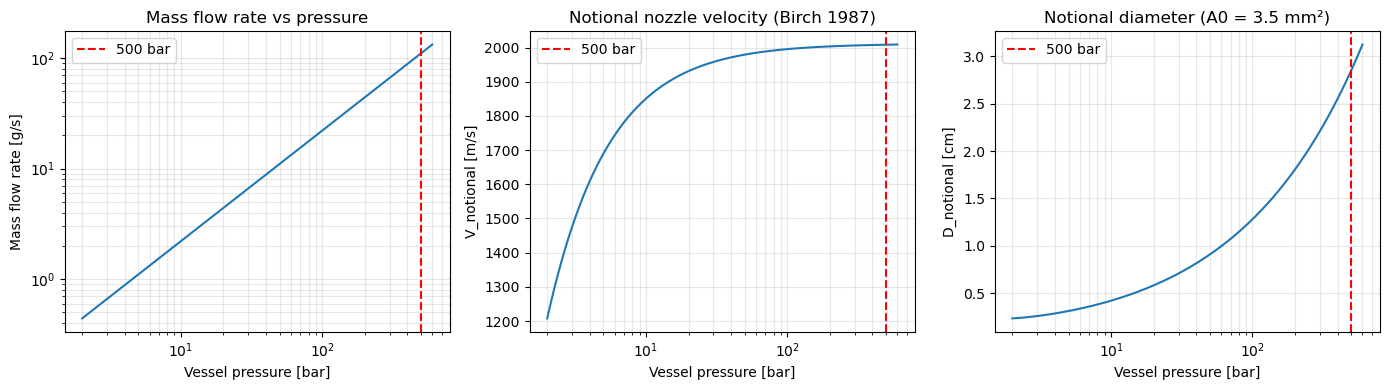

At 500 bar, A0=3.5mm²: V_n=2008 m/s, D_n=2.9 cm


In [9]:
# ── Sensitivity: D_n and V_n vs vessel pressure ─────────────────────────────
P0_range = np.logspace(np.log10(2e5), np.log10(600e5), 200)  # 2 bar to 600 bar
A0 = 3.5e-6  # 3.5 mm²

T_thr = 2 * T0 / (gamma + 1)
P_thr = P0_range * (2 / (gamma + 1))**(gamma / (gamma - 1))
rho_thr = P_thr / (R_H2 * T_thr)
V_thr = np.sqrt(gamma * R_H2 * T_thr) * np.ones_like(P0_range)  # constant!

V_notional = V_thr + (P_thr - P_amb) / (rho_thr * V_thr)
mdot = rho_thr * V_thr * A0
A_notional = mdot / (rho_n * V_notional)
D_notional = np.sqrt(4 * A_notional / np.pi) * 100  # cm

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].loglog(P0_range / 1e5, mdot * 1000)
axes[0].axvline(500, color='red', linestyle='--', label='500 bar')
axes[0].set_xlabel('Vessel pressure [bar]')
axes[0].set_ylabel('Mass flow rate [g/s]')
axes[0].set_title('Mass flow rate vs pressure')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

axes[1].semilogx(P0_range / 1e5, V_notional)
axes[1].axvline(500, color='red', linestyle='--', label='500 bar')
axes[1].set_xlabel('Vessel pressure [bar]')
axes[1].set_ylabel('V_notional [m/s]')
axes[1].set_title('Notional nozzle velocity (Birch 1987)')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

axes[2].semilogx(P0_range / 1e5, D_notional)
axes[2].axvline(500, color='red', linestyle='--', label='500 bar')
axes[2].set_xlabel('Vessel pressure [bar]')
axes[2].set_ylabel('D_notional [cm]')
axes[2].set_title(f'Notional diameter (A0 = 3.5 mm²)')
axes[2].legend()
axes[2].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('notional_nozzle_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"At 500 bar, A0=3.5mm²: V_n={V_notional[np.argmin(np.abs(P0_range-500e5))]:.0f} m/s, "
      f"D_n={D_notional[np.argmin(np.abs(P0_range-500e5))]:.1f} cm")

---
## 8. OpenFOAM Boundary Conditions

### Summary table

| Field | Source patch (notional nozzle) | Outlets | Walls |
|-------|-------------------------------|---------|-------|
| `U` | `fixedValue (0 0 V_n)` | `pressureInletOutletVelocity` | `noSlip` |
| `p` | `fixedValue 101325` | `waveTransmissive` or `totalPressure` | `zeroGradient` |
| `T` | `fixedValue T_n` | `inletOutlet T_amb` | `zeroGradient` |
| `H2` | `fixedValue 1.0` | `inletOutlet 0.0` | `zeroGradient` |
| `k` | `fixedValue k_inlet` | `inletOutlet k_amb` | `kqRWallFunction` |
| `epsilon` | `fixedValue eps_inlet` | `inletOutlet eps_amb` | `epsilonWallFunction` |

### Turbulence inlet conditions

Turbulence intensity $I = 0.05$ (5%), length scale $l = 0.07 D_n$:

$$k_{inlet} = \frac{3}{2} (I \, V_n)^2$$

$$\varepsilon_{inlet} = C_\mu^{3/4} \frac{k_{inlet}^{3/2}}{l}, \quad C_\mu = 0.09$$

### Source patch geometry (500 bar, 3.5 mm² orifice)

From the Birch 1987 calculation:

| Shape | Dimension | Value |
|-------|-----------|-------|
| Circle | Diameter D_n | **2.85 cm** |
| Square | Side length | **2.53 cm (25.3 mm)** |
| Both | Area A_n | 6.38 cm² |

For a square source patch in the mesh (e.g. defined in Blender/STL), use a **25.3 mm × 25.3 mm** face.  
The current case04 source patch is ~20 mm × 20 mm — needs to be enlarged to ~25.3 mm × 25.3 mm.


In [10]:
# ── Print OpenFOAM BC values for 500 bar, 3.5 mm² case ─────────────────────
A0 = 3.5e-6
mdot = rho_throat * V_throat * A0
A_n_final = mdot / (rho_n * V_n)
D_n_final = np.sqrt(4 * A_n_final / np.pi)

# Turbulence parameters
I = 0.05
C_mu = 0.09
l = 0.07 * D_n_final
k_in = 1.5 * (I * V_n)**2
eps_in = C_mu**(3/4) * k_in**(3/2) / l

print("=" * 55)
print("OpenFOAM boundary condition values")
print("Case: 500 bar, A0 = 3.5 mm², Birch 1987")
print("=" * 55)
print(f"  Source patch velocity  U = (0 0 {V_n:.0f}) m/s")
print(f"  Source patch pressure  p = {P_amb:.0f} Pa")
print(f"  Source patch temperature T = {T_n:.2f} K")
print(f"  Source patch H2 mass frac = 1.0")
print(f"  Notional diameter      D_n = {D_n_final*100:.1f} cm")
print(f"  Notional area          A_n = {A_n_final*1e4:.1f} cm²")
print(f"  Mass flow rate         mdot = {mdot*1000:.2f} g/s = {mdot:.4f} kg/s")
print(f"")
print(f"  Turbulence intensity   I = {I*100:.0f}%")
print(f"  Mixing length          l = {l*100:.1f} cm")
print(f"  k_inlet  = {k_in:.1f} m²/s²")
print(f"  eps_inlet = {eps_in:.1f} m²/s³")
# ── Square nozzle equivalent ─────────────────────────────────────────────────
side_sq = np.sqrt(A_n_final)
print(f"  Equivalent square side = {side_sq*100:.3f} cm = {side_sq*1000:.2f} mm")
print(f"  (same area as circular D_n, for use with rectangular mesh patches)")


OpenFOAM boundary condition values
Case: 500 bar, A0 = 3.5 mm², Birch 1987
  Source patch velocity  U = (0 0 2008) m/s
  Source patch pressure  p = 101325 Pa
  Source patch temperature T = 286.15 K
  Source patch H2 mass frac = 1.0
  Notional diameter      D_n = 2.9 cm
  Notional area          A_n = 6.4 cm²
  Mass flow rate         mdot = 110.31 g/s = 0.1103 kg/s

  Turbulence intensity   I = 5%
  Mixing length          l = 0.2 cm
  k_inlet  = 15124.1 m²/s²
  eps_inlet = 152982347.4 m²/s³
  Equivalent square side = 2.529 cm = 25.29 mm
  (same area as circular D_n, for use with rectangular mesh patches)


### Example 0/U snippet for OpenFOAM

```cpp
source
{
    type            fixedValue;
    value           uniform (0 0 2180);   // V_notional [m/s] — update with computed value
}
```

### Example 0/p snippet

```cpp
source
{
    type            fixedValue;
    value           uniform 101325;       // P_ambient [Pa]
}
```

### Key difference from case04

In **case04**, the source was set to `zeroGradient` for pressure and `fixedValue (0 0 1630)` for U. The pressure was not explicitly constrained to ambient, which means the solver was trying to maintain 500 bar at the inlet — the actual physical pressure — which then drove a supersonic underexpanded jet and triggered the shock/temperature blow-up.

With the notional nozzle approach, **explicitly fixing p = P_ambient at the source is essential**.

---
## 9. References

1. **Birch, A.D., Brown, D.R., Dodson, M.G., Swaffield, F.** (1984).  
   *The structure and concentration decay of high pressure jets of natural gas.*  
   Combustion Science and Technology, 36(5-6), 249–261.  
   → Introduced the notional nozzle concept; mass conservation only.

2. **Birch, A.D., Hughes, D.J., Swaffield, F.** (1987).  
   *Velocity decay in high pressure jets.*  
   Combustion Science and Technology, 52(1-3), 161–171.  
   → Extended to mass + momentum conservation (pressure thrust term); **recommended for H2 dispersion**.

3. **Ewan, B.C.R., Moodie, K.** (1986).  
   *Structure and velocity measurements in underexpanded jets.*  
   Combustion Science and Technology, 45(5-6), 275–288.  
   → Alternative mass-only model.

4. **Schefer, R.W., Houf, W.G., Williams, T.C.** (2007).  
   *Investigation of small-scale unintended releases of hydrogen: buoyancy effects.*  
   International Journal of Hydrogen Energy, 33(17), 4702–4712.  
   → Mass + momentum + energy model; best temperature accuracy.

5. **Baraldi, D., Melideo, D., Kotchourko, A., Heitsch, M., Caruso, G., Gallego, E., ... & Studer, E.** (2017).  
   *Development of a model evaluation methodology for CFD simulation of hydrogen safety-relevant scenarios.*  
   International Journal of Hydrogen Energy, 42(11), 7633–7643.

6. **Baraldi, D., Papanikolaou, E., Heitsch, M., Moretto, P., Cant, R.S., Roekaerts, D., ... & Dorofeev, S.** (2012).  
   *Computational study of highly underexpanded hydrogen jets.*  
   Proceedings of the 4th International Conference on Hydrogen Safety (ICHS).  
   → Benchmarks 5 notional nozzle models against experiments; Birch 1987 and Schefer best performers.

7. **Keenan, J.J., Makarov, D.V., Molkov, V.V.** (2014).  
   *Rayleigh-Taylor instability: Modelling and effect on coherent deflagrations.*  
   International Journal of Hydrogen Energy, 39(35), 20467–20473.  
   → OpenFOAM + reactingFoam + notional nozzle for high-pressure H2 indoor dispersion.

8. **Molkov, V., Makarov, D., Bragin, M.** (2009).  
   *Physics and modelling of under-expanded jets and hydrogen dispersion in atmosphere.*  
   Physics of Extreme States of Matter, 146–149.  
   → Detailed physics of underexpanded H2 jets and pseudo-source approach.

9. **HySafe BRHS (Biennial Report on Hydrogen Safety)**, Chapter 3.  
   Available at: www.hysafe.info  
   → Comprehensive review of H2 release and dispersion modeling best practices.

---

### Quick reference formulas

| Quantity | Formula | Notes |
|----------|---------|-------|
| $T_{throat}$ | $\dfrac{2 T_0}{\gamma+1}$ | Isentropic, Mach 1 |
| $P_{throat}$ | $P_0 \left(\dfrac{2}{\gamma+1}\right)^{\gamma/(\gamma-1)}$ | Critical pressure |
| $V_{throat}$ | $\sqrt{\gamma R T_{throat}}$ | Speed of sound at throat |
| $\rho_{throat}$ | $P_{throat} / (R T_{throat})$ | Ideal gas |
| $\dot{m}$ | $\rho_{throat} V_{throat} A_0$ | Mass flow (choked) |
| $V_n$ (Birch 87) | $V_{throat} + \dfrac{P_{throat}-P_{amb}}{\rho_{throat} V_{throat}}$ | Notional velocity |
| $D_n$ | $D_0 \sqrt{\dfrac{\rho_{throat} V_{throat}}{\rho_n V_n}}$ | Notional diameter |